In [1]:
import os
import csv
import random

DATASET_DIR = "CroppedFaces"
OUTPUT_MANIFEST = "manifest_new.csv"

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])

class_to_label = {cls: idx for idx, cls in enumerate(class_names)}
class_wise_files = {cls: [] for cls in class_names}

for cls in class_names:
    cls_path = os.path.join(DATASET_DIR, cls)

    for root, _, files in os.walk(cls_path):
        for file in files:
            if file.lower().endswith(IMAGE_EXTENSIONS):
                class_wise_files[cls].append(os.path.join(root, file))

manifest_rows = []

for cls, files in class_wise_files.items():
    random.shuffle(files)

    total = len(files)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    for i, file_path in enumerate(files):
        if i < train_end:
            split = "train"
        elif i < val_end:
            split = "val"
        else:
            split = "test"

        manifest_rows.append([
            file_path,
            class_to_label[cls],
            cls,
            split
        ])
with open(OUTPUT_MANIFEST, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["file_path", "label", "class_name", "split"])
    writer.writerows(manifest_rows)

print(f"Manifest created: {OUTPUT_MANIFEST}")
print(f"Total samples: {len(manifest_rows)}")


Manifest created: manifest_new.csv
Total samples: 28410


In [2]:
#Feature Extraction + Training Pipeline

import cv2
import numpy as np
import pandas as pd
import time
from collections import defaultdict

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

MANIFEST = "manifest_new.csv"
IMG_SIZE = 224
GRID = (4, 4)
LOG_EVERY = 100
EPS = 1e-6

SIGMA_LOW = 0.8
SIGMA_HIGH = 1.6
SAT_THRESH = 252

OUT_CSV = "features_ALL_1.csv"

def dog_filter(img):
    b1 = cv2.GaussianBlur(img, (0, 0), SIGMA_LOW)
    b2 = cv2.GaussianBlur(img, (0, 0), SIGMA_HIGH)
    return b1 - b2

def grid_iterator(img):
    h, w = img.shape
    gh, gw = GRID
    fh, fw = h // gh, w // gw
    for i in range(gh):
        for j in range(gw):
            yield img[i*fh:(i+1)*fh, j*fw:(j+1)*fw]

def fmi_features(fringe):
    vals = []
    for roi in grid_iterator(fringe):
        mu = np.mean(roi)
        sigma = np.std(roi)
        vals.append(sigma / (np.abs(mu) + EPS))
    vals = np.array(vals)
    return vals.mean(), vals.var(), vals.max() - vals.min()

def ftp_features(fringe):
    gx = cv2.Sobel(fringe, cv2.CV_32F, 1, 0, 3)
    gy = cv2.Sobel(fringe, cv2.CV_32F, 0, 1, 3)
    grad = np.sqrt(gx**2 + gy**2)

    th = np.percentile(fringe, 75)
    mask = fringe > th

    vals = []
    for roi_g, roi_m in zip(grid_iterator(grad), grid_iterator(mask)):
        if np.sum(roi_m) < 10:
            vals.append(0.0)
        else:
            vals.append(np.mean(roi_g[roi_m]))
    vals = np.array(vals)
    return vals.mean(), vals.var(), vals.max() - vals.min()

def orientation_features(fringe):
    gx = cv2.Sobel(fringe, cv2.CV_32F, 1, 0, 3)
    gy = cv2.Sobel(fringe, cv2.CV_32F, 0, 1, 3)

    th = np.percentile(fringe, 75)
    mask = fringe > th

    coh = []
    for roi_x, roi_y, roi_m in zip(
        grid_iterator(gx), grid_iterator(gy), grid_iterator(mask)
    ):
        if np.sum(roi_m) < 10:
            coh.append(0.0)
        else:
            theta = np.arctan2(roi_y[roi_m], roi_x[roi_m])
            coh.append(np.abs(np.mean(np.exp(1j * 2 * theta))))
    coh = np.array(coh)
    return coh.mean(), coh.var(), coh.max() - coh.min()

def spectral_features(img_color):
    b, g, r = cv2.split(img_color)

    r_f = np.abs(dog_filter(r.astype(np.float32)))
    g_f = np.abs(dog_filter(g.astype(np.float32)))
    b_f = np.abs(dog_filter(b.astype(np.float32)))

    fmi_r = fmi_features(r_f)[0]
    fmi_g = fmi_features(g_f)[0]
    fmi_b = fmi_features(b_f)[0]

    return (
        fmi_r, fmi_g, fmi_b,
        abs(fmi_r - fmi_g),
        abs(fmi_r - fmi_b),
        abs(fmi_g - fmi_b)
    )

def screen_features(gray):
    fringe = dog_filter(gray.astype(np.float32))
    residual = np.clip(gray - fringe, 0, 255).astype(np.uint8)

    sat = np.sum(residual >= SAT_THRESH) / residual.size

    f = np.fft.fftshift(np.fft.fft2(residual.astype(np.float32)))
    mag = np.abs(f)
    h, w = mag.shape
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((Y - cy)**2 + (X - cx)**2)

    hf = np.sum(mag[dist > 60]) / (np.sum(mag) + EPS)
    return sat, hf

# ==========================================================
# MAIN FEATURE EXTRACTION
# ==========================================================

df = pd.read_csv(MANIFEST)
rows = []
counter = defaultdict(int)

start = time.time()
print(f"🚀 ML3: Extracting features from {len(df)} images")

for idx, row in enumerate(df.itertuples(index=False), 1):
    img_gray = cv2.imread(row.file_path, cv2.IMREAD_GRAYSCALE)
    img_color = cv2.imread(row.file_path, cv2.IMREAD_COLOR)

    if img_gray is None or img_color is None:
        continue

    img_gray = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
    img_color = cv2.resize(img_color, (IMG_SIZE, IMG_SIZE))

    fringe = np.abs(dog_filter(img_gray.astype(np.float32)))
    fringe /= (np.max(fringe) + EPS)

    fmi = fmi_features(fringe)
    ftp = ftp_features(fringe)
    ori = orientation_features(fringe)
    spec = spectral_features(img_color)
    scr = screen_features(img_gray)

    rows.append([
        row.file_path, row.label, row.class_name, row.split,
        *fmi, *ftp, *ori, *spec, *scr
    ])

    counter[row.class_name] += 1

    if idx % LOG_EVERY == 0:
        print(f"{idx}/{len(df)} processed | {time.time()-start:.1f}s")

# ==========================================================
# SAVE OUTPUTS
# ==========================================================

columns = [
    "file_path", "label", "class_name", "split",
    "fmi_mean", "fmi_var", "fmi_range",
    "ftp_mean", "ftp_var", "ftp_range",
    "ori_mean", "ori_var", "ori_range",
    "spec_fmi_r", "spec_fmi_g", "spec_fmi_b",
    "spec_rg_diff", "spec_rb_diff", "spec_gb_diff",
    "saturation_ratio", "high_freq_ratio"
]

df_out = pd.DataFrame(rows, columns=columns)
df_out.to_csv(OUT_CSV, index=False)

X = df_out[[c for c in columns if c not in ["file_path", "label", "class_name", "split"]]].values
y = df_out["label"].values

np.save("X_features.npy", X)
np.save("y_labels.npy", y)

print("✅ ML3 feature extraction completed")
print("📊 Class counts:", dict(counter))


🚀 ML3: Extracting features from 28410 images
100/28410 processed | 4.8s
200/28410 processed | 9.6s
300/28410 processed | 14.6s
400/28410 processed | 19.5s
500/28410 processed | 24.1s
600/28410 processed | 28.8s
700/28410 processed | 33.7s
800/28410 processed | 38.6s
900/28410 processed | 43.3s
1000/28410 processed | 48.1s
1100/28410 processed | 53.0s
1200/28410 processed | 58.3s
1300/28410 processed | 63.4s
1400/28410 processed | 68.2s
1500/28410 processed | 73.0s
1600/28410 processed | 77.9s
1700/28410 processed | 82.8s
1800/28410 processed | 87.6s
1900/28410 processed | 92.5s
2000/28410 processed | 97.4s
2100/28410 processed | 102.2s
2200/28410 processed | 107.1s
2300/28410 processed | 111.9s
2400/28410 processed | 116.9s
2500/28410 processed | 121.8s
2600/28410 processed | 126.7s
2700/28410 processed | 131.7s
2800/28410 processed | 136.6s
2900/28410 processed | 141.4s
3000/28410 processed | 146.2s
3100/28410 processed | 151.0s
3200/28410 processed | 155.9s
3300/28410 processed | 160

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ================= LOAD DATA =================
df = pd.read_csv("features_ALL_1.csv")

FEATURE_COLS = [
    c for c in df.columns
    if c not in ["file_path", "label", "class_name", "split"]
]

X_train = df[df["split"] == "train"][FEATURE_COLS].values
y_train = df[df["split"] == "train"]["label"].values

X_val = df[df["split"] == "val"][FEATURE_COLS].values
y_val = df[df["split"] == "val"]["label"].values

X_test = df[df["split"] == "test"][FEATURE_COLS].values
y_test = df[df["split"] == "test"]["label"].values

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (19884, 17) Val: (4260, 17) Test: (4266, 17)


In [4]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


C:\Users\adars\PycharmProjects\PythonProject\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


===== LOGISTIC REGRESSION =====
Accuracy: 0.8795124238162213
              precision    recall  f1-score   support

           0       0.78      0.88      0.83      1076
           1       0.88      0.79      0.83      1425
           2       0.97      0.95      0.96      1142
           3       0.94      0.96      0.95       405
           4       0.82      1.00      0.90       218

    accuracy                           0.88      4266
   macro avg       0.88      0.91      0.89      4266
weighted avg       0.88      0.88      0.88      4266



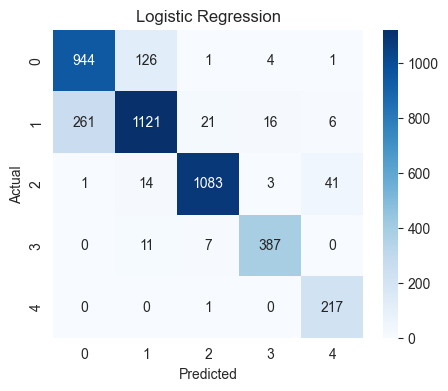

In [5]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        multi_class="multinomial",
        class_weight="balanced"
    ))
])

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print("===== LOGISTIC REGRESSION =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, "Logistic Regression")


===== SVM (RBF) =====
Accuracy: 0.9655414908579466
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1076
           1       0.96      0.94      0.95      1425
           2       0.99      0.98      0.99      1142
           3       1.00      1.00      1.00       405
           4       0.96      1.00      0.98       218

    accuracy                           0.97      4266
   macro avg       0.97      0.98      0.97      4266
weighted avg       0.97      0.97      0.97      4266



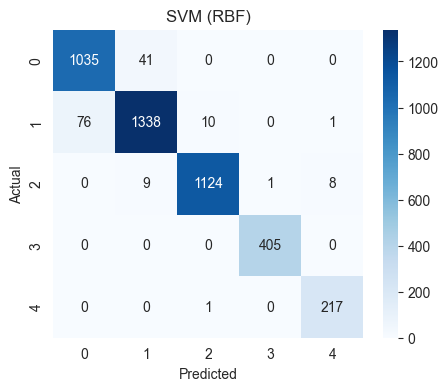

In [6]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced"
    ))
])

svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print("===== SVM (RBF) =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, "SVM (RBF)")


===== RANDOM FOREST =====
Accuracy: 0.9716361931551805
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1076
           1       0.96      0.98      0.97      1425
           2       0.98      0.98      0.98      1142
           3       0.99      0.98      0.99       405
           4       0.95      0.95      0.95       218

    accuracy                           0.97      4266
   macro avg       0.97      0.97      0.97      4266
weighted avg       0.97      0.97      0.97      4266



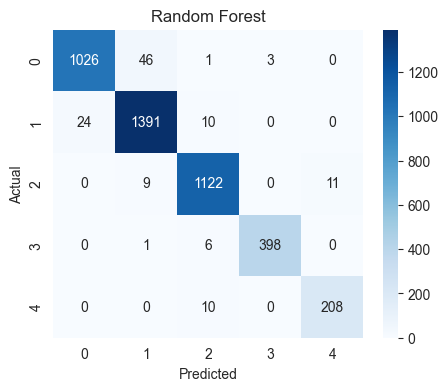

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("===== RANDOM FOREST =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, "Random Forest")


In [8]:
importances = rf.feature_importances_

imp_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("🔝 Top 10 Most Important Features")
print(imp_df.head(10))


🔝 Top 10 Most Important Features
            feature  importance
1           fmi_var    0.136768
9        spec_fmi_r    0.089813
0          fmi_mean    0.088258
10       spec_fmi_g    0.081746
2         fmi_range    0.078105
11       spec_fmi_b    0.070329
16  high_freq_ratio    0.070276
6          ori_mean    0.065511
13     spec_rb_diff    0.056896
4           ftp_var    0.056805


PHASE 2 -- K-fold


In [9]:
import pandas as pd
import numpy as np

# ================= LOAD FEATURES =================
df = pd.read_csv("features_ALL_1.csv")

FEATURE_COLS = [
    c for c in df.columns
    if c not in ["file_path", "label", "class_name", "split"]
]

X = df[FEATURE_COLS].values
y = df["label"].values

print("Total samples:", X.shape[0])
print("Feature dimension:", X.shape[1])

print("\nClass distribution:")
print(df["class_name"].value_counts())


Total samples: 28410
Feature dimension: 17

Class distribution:
class_name
attack_print_color    9500
attack_screen         7607
attack_print_bw       7168
real_fringe           2691
real_no_fringe        1444
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# Reload to be safe
df = pd.read_csv("features_ALL_1.csv")

FEATURE_COLS = [
    c for c in df.columns
    if c not in ["file_path", "label", "class_name", "split"]
]

X = df[FEATURE_COLS].values
y = df["label"].values

# ================= STRATIFIED K-FOLD =================
N_SPLITS = 5
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

print(f"Using {N_SPLITS}-Fold Stratified Cross-Validation\n")

# ===== CHECK CLASS DISTRIBUTION PER FOLD =====
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    y_test = y[test_idx]
    unique, counts = np.unique(y_test, return_counts=True)

    print(f"Fold {fold} test distribution:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c}")
    print("-" * 30)


Using 5-Fold Stratified Cross-Validation

Fold 1 test distribution:
  Class 0: 1434
  Class 1: 1900
  Class 2: 1521
  Class 3: 539
  Class 4: 288
------------------------------
Fold 2 test distribution:
  Class 0: 1434
  Class 1: 1900
  Class 2: 1521
  Class 3: 538
  Class 4: 289
------------------------------
Fold 3 test distribution:
  Class 0: 1434
  Class 1: 1900
  Class 2: 1521
  Class 3: 538
  Class 4: 289
------------------------------
Fold 4 test distribution:
  Class 0: 1433
  Class 1: 1900
  Class 2: 1522
  Class 3: 538
  Class 4: 289
------------------------------
Fold 5 test distribution:
  Class 0: 1433
  Class 1: 1900
  Class 2: 1522
  Class 3: 538
  Class 4: 289
------------------------------


In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# ================= LOAD DATA =================
df = pd.read_csv("features_ALL_1.csv")

FEATURE_COLS = [
    c for c in df.columns
    if c not in ["file_path", "label", "class_name", "split"]
]

X = df[FEATURE_COLS].values
y = df["label"].values

# ================= STRATIFIED K-FOLD =================
N_SPLITS = 5
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

fold_accuracies = []

print("🚀 Starting 5-Fold CV with SVM (RBF)\n")

# ================= K-FOLD LOOP =================
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    fold_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")

# ================= SUMMARY =================
fold_accuracies = np.array(fold_accuracies)

print("\n📊 5-Fold CV Results (SVM)")
print("Mean Accuracy:", fold_accuracies.mean())
print("Std Deviation:", fold_accuracies.std())


🚀 Starting 5-Fold CV with SVM (RBF)

Fold 1 Accuracy: 0.9620
Fold 2 Accuracy: 0.9630
Fold 3 Accuracy: 0.9636
Fold 4 Accuracy: 0.9662
Fold 5 Accuracy: 0.9590

📊 5-Fold CV Results (SVM)
Mean Accuracy: 0.9627595916930657
Std Deviation: 0.0023417173359352042


🚀 Collecting predictions across folds...

Fold 1 collected
Fold 2 collected
Fold 3 collected
Fold 4 collected
Fold 5 collected

📊 Aggregated Confusion Matrix (5-Fold CV)
[[6785  377    2    3    1]
 [ 486 8944   62    5    3]
 [   2   41 7501    9   54]
 [   1    1    3 2685    1]
 [   0    2    5    0 1437]]


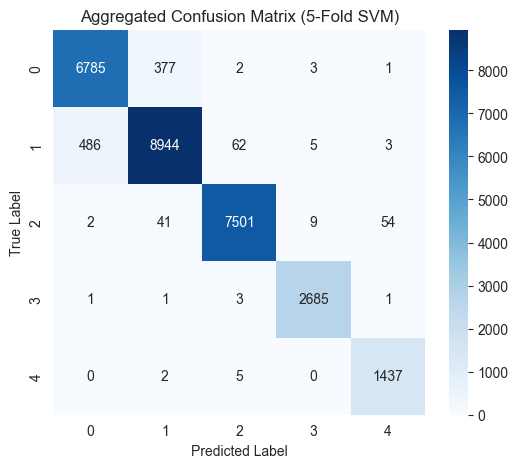


📄 Aggregated Classification Report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7168
           1       0.96      0.94      0.95      9500
           2       0.99      0.99      0.99      7607
           3       0.99      1.00      1.00      2691
           4       0.96      1.00      0.98      1444

    accuracy                           0.96     28410
   macro avg       0.97      0.97      0.97     28410
weighted avg       0.96      0.96      0.96     28410



In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================= LOAD DATA =================
df = pd.read_csv("features_ALL_1.csv")

FEATURE_COLS = [
    c for c in df.columns
    if c not in ["file_path", "label", "class_name", "split"]
]

X = df[FEATURE_COLS].values
y = df["label"].values

# ================= STRATIFIED K-FOLD =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_y_true = []
all_y_pred = []

print("🚀 Collecting predictions across folds...\n")

# ================= K-FOLD LOOP =================
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    print(f"Fold {fold} collected")

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(all_y_true, all_y_pred)

print("\n📊 Aggregated Confusion Matrix (5-Fold CV)")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Aggregated Confusion Matrix (5-Fold SVM)")
plt.show()

# ================= CLASSIFICATION REPORT =================
print("\n📄 Aggregated Classification Report")
print(classification_report(all_y_true, all_y_pred))


In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import joblib

# ================= LOAD DATA =================
df = pd.read_csv("features_ALL_1.csv")

FEATURE_COLS = [
    c for c in df.columns
    if c not in ["file_path", "label", "class_name", "split"]
]

X = df[FEATURE_COLS].values
y = df["label"].values

# ================= STRATIFIED K-FOLD =================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ================= MODELS =================
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            multi_class="multinomial",
            class_weight="balanced"
        ))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced"
        ))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

# ================= K-FOLD EVALUATION =================
results = {}

print("🚀 Starting 5-Fold CV Model Comparison\n")

for name, model in models.items():
    fold_acc = []

    print(f"🔹 Model: {name}")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        fold_acc.append(acc)

        print(f"  Fold {fold} Accuracy: {acc:.4f}")

    fold_acc = np.array(fold_acc)
    mean_acc = fold_acc.mean()
    std_acc = fold_acc.std()

    results[name] = mean_acc

    print(f"  ➜ Mean: {mean_acc:.4f}, Std: {std_acc:.4f}")
    print("-" * 45)

# ================= SELECT BEST MODEL =================
best_model_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model_name}")

best_model = models[best_model_name]

# ================= TRAIN FINAL MODEL ON FULL DATA =================
print("\n🚀 Training best model on FULL dataset...")

best_model.fit(X, y)

# ================= SAVE MODEL =================
joblib.dump(best_model, "rgb_model.pkl")

print("✅ Model saved as rgb_model.pkl")

🚀 Starting 5-Fold CV Model Comparison

🔹 Model: Logistic Regression


C:\Users\adars\PycharmProjects\PythonProject\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 1 Accuracy: 0.8719


C:\Users\adars\PycharmProjects\PythonProject\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 2 Accuracy: 0.8796


...

  Fold 3 Accuracy: 0.8763


C:\Users\adars\PycharmProjects\PythonProject\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 4 Accuracy: 0.8837


C:\Users\adars\PycharmProjects\PythonProject\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 5 Accuracy: 0.8784
  ➜ Mean: 0.8780, Std: 0.0039
---------------------------------------------
🔹 Model: SVM (RBF)
  Fold 1 Accuracy: 0.9620
  Fold 2 Accuracy: 0.9630
  Fold 3 Accuracy: 0.9636
  Fold 4 Accuracy: 0.9662
  Fold 5 Accuracy: 0.9590
  ➜ Mean: 0.9628, Std: 0.0023
---------------------------------------------
🔹 Model: Random Forest
  Fold 1 Accuracy: 0.9715
  Fold 2 Accuracy: 0.9678
  Fold 3 Accuracy: 0.9699
  Fold 4 Accuracy: 0.9703
  Fold 5 Accuracy: 0.9678
  ➜ Mean: 0.9694, Std: 0.0014
---------------------------------------------

🏆 Best Model: Random Forest

🚀 Training best model on FULL dataset...
✅ Model saved as rgb_model.pkl
